# Aprendizaje Supervisado — Detección de Anomalías

## Librerías

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('../src').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from lightgbm import LGBMClassifier

from modelos_supervisados import construir_features, plot_roc_curve


## Rutas

In [2]:
PATH      = '../data/EMCALI/datos_procesados/'
PATH_INSP = '../data/EMCALI/'
PATH_OUT  = '../data/Resultados/'

## Lectura de datos

In [3]:
inspecciones       = pd.read_csv(PATH + 'info_inspecciones.csv')
consumo            = pd.read_parquet(PATH + 'consumo_011223_01062025_filtrado.parquet')

In [4]:
inspecciones.shape

(9721, 12)

## Limpieza

In [5]:
consumo.dropna(subset='consumo', inplace=True)
inspecciones.dropna(subset='anomalo', inplace=True)

# Conservar solo productos presentes en ambas bases
inspecciones = inspecciones[inspecciones.producto.isin(consumo.producto)]
consumo = consumo[consumo.producto.isin(inspecciones.producto)]

print('inspecciones_fin:', inspecciones.shape, '| consumo:', consumo.shape)

inspecciones_fin: (9721, 12) | consumo: (172254, 11)


## Consolidar consumo + etiquetas

In [6]:
df_consolidado = inspecciones.merge(consumo, on='producto')
df_consolidado = df_consolidado[[c for c in df_consolidado.columns if 'Anomalia' not in c]]
df_consolidado.drop(columns=['fecha_visita'], inplace=True)
print(df_consolidado.shape, '| productos únicos:', df_consolidado.producto.nunique())

(184699, 17) | productos únicos: 9066


## Feature engineering

In [7]:
X, y, cat_cols = construir_features(df_consolidado, incluir_target=True)
X.to_csv(PATH_OUT + 'X_full_features_manuales_V1.csv', index=False)
print('X:', X.shape, '| anomalos:', y.sum(), '/ normales:', (y==0).sum())


Construyendo features: 100%|██████████| 9066/9066 [00:07<00:00, 1287.93it/s]


X: (9066, 13) | anomalos: 3630 / normales: 5436


## Train / Validation split

In [8]:
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pre = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')


## Modelo 1: Gradient Boosting (baseline)

In [9]:
clf_gb = Pipeline([('pre', pre), ('gb', GradientBoostingClassifier(random_state=42))])
clf_gb.fit(Xtr, ytr)
p_gb = clf_gb.predict_proba(Xva)[:, 1]
print('Gradient Boosting AUC:', roc_auc_score(yva, p_gb))
print(classification_report(yva, (p_gb >= 0.5).astype(int), digits=3))


Gradient Boosting AUC: 0.710128524550316
              precision    recall  f1-score   support

           0      0.653     0.965     0.779      1088
           1      0.816     0.233     0.362       726

    accuracy                          0.672      1814
   macro avg      0.735     0.599     0.571      1814
weighted avg      0.719     0.672     0.612      1814



## Modelo 2: Random Forest

In [10]:
clf_rf = Pipeline([
    ('pre', pre),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
clf_rf.fit(Xtr, ytr)
p_rf = clf_rf.predict_proba(Xva)[:, 1]
print('Random Forest AUC:', roc_auc_score(yva, p_rf))
print(classification_report(yva, (p_rf >= 0.5).astype(int), digits=3))


Random Forest AUC: 0.7092999260654674
              precision    recall  f1-score   support

           0      0.686     0.834     0.752      1088
           1      0.631     0.427     0.509       726

    accuracy                          0.671      1814
   macro avg      0.658     0.630     0.631      1814
weighted avg      0.664     0.671     0.655      1814



## Modelo 3: LightGBM

In [11]:
clf_lgbm = Pipeline([
    ('pre', pre),
    ('lgbm', LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        importance_type='gain',
    ))
])
clf_lgbm.fit(Xtr, ytr)
p_lgbm = clf_lgbm.predict_proba(Xva)[:, 1]
print('LightGBM AUC:', roc_auc_score(yva, p_lgbm))
print(classification_report(yva, (p_lgbm >= 0.5).astype(int), digits=3))


[LightGBM] [Info] Number of positive: 2904, number of negative: 4348
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000897 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2256
[LightGBM] [Info] Number of data points in the train set: 7252, number of used features: 116
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400441 -> initscore=-0.403627
[LightGBM] [Info] Start training from score -0.403627
LightGBM AUC: 0.7095740155566358
              precision    recall  f1-score   support

           0      0.679     0.844     0.752      1088
           1      0.632     0.402     0.492       726

    accuracy                          0.667      1814
   macro avg      0.656     0.623     0.622      1814
weighted avg      0.660     0.667     0.648      1814



## Curvas ROC comparativas

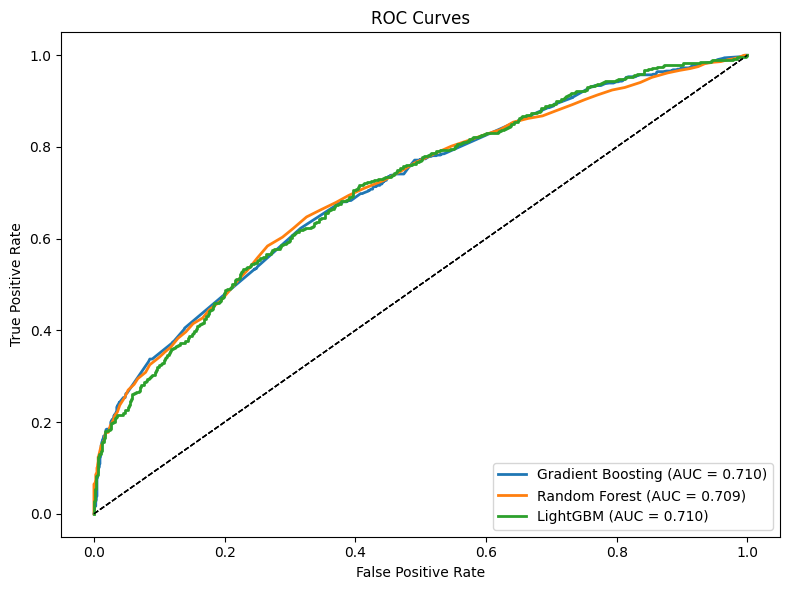

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_curve(clf_gb,   Xva, yva, 'Gradient Boosting', ax=ax)
plot_roc_curve(clf_rf,   Xva, yva, 'Random Forest',     ax=ax)
plot_roc_curve(clf_lgbm, Xva, yva, 'LightGBM',          ax=ax,
               out_path=PATH_OUT + 'roc_curves_supervisados.png')
plt.tight_layout()
plt.show()


## Matrices de confusión

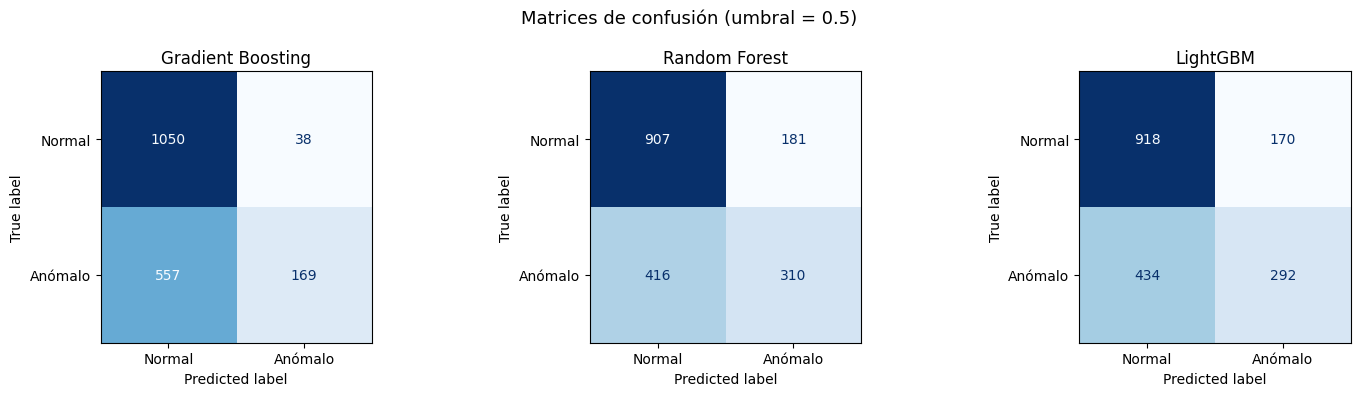

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modelos = [
    (clf_gb,   p_gb,   'Gradient Boosting'),
    (clf_rf,   p_rf,   'Random Forest'),
    (clf_lgbm, p_lgbm, 'LightGBM'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (clf, proba, nombre) in zip(axes, modelos):
    y_pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(yva, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anómalo'])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)

fig.suptitle('Matrices de confusión (umbral = 0.5)', fontsize=13)
plt.tight_layout()
plt.show()


## Predicción en dataset completo

Aplica el mejor modelo (LightGBM) sobre todos los clientes del dataset filtrado.

In [35]:
consumo_completo = pd.read_parquet(PATH + 'consumo_011223_01062025_filtrado.parquet')
X_completo, _ = construir_features(consumo_completo, incluir_target=False)

# Recuperar IDs de producto
productos_ids = consumo_completo.groupby('producto').size().index
X_completo['producto'] = productos_ids.values

X_completo['prediccion_lgbm'] = clf_lgbm.predict_proba(X_completo.drop(columns='producto'))[:, 1]
#X_completo['prediccion_rf']   = clf_rf.predict_proba(X_completo.drop(columns=['producto','prediccion_lgbm']))[:, 1]

X_completo.to_csv(PATH_OUT + 'supervisado_predicciones_completo.csv', index=False)

Construyendo features: 100%|██████████| 596275/596275 [11:33<00:00, 859.46it/s]  


In [36]:
X_completo

,consumo_mean,consumo_std,consumo_min,consumo_max,consumo_last,pct_mean,pct_std,trend,categoria,subcategoria,tipo_producto,localidad,barrio,producto,prediccion_lgbm
0,160.263158,21.351302,129.00000,205.000000,195.0,0.021219,0.163941,0.856140,1.0,1.0,6140.0,76001.0,102.0,41,0.394695
1,96.421053,8.904853,76.00000,111.000000,103.0,0.010622,0.130704,0.007018,1.0,1.0,6140.0,76001.0,102.0,45,0.515146
2,154.315789,45.913021,67.00000,201.000000,67.0,-0.013220,0.168485,-2.845614,1.0,1.0,6140.0,76001.0,102.0,49,0.390380
3,167.368421,102.292260,46.00000,318.000000,47.0,-0.044850,0.213828,-15.256140,1.0,1.0,6140.0,76001.0,102.0,100,0.444962
4,191.684211,21.511448,126.00000,225.000000,210.0,0.037997,0.158124,2.092982,1.0,1.0,6140.0,76001.0,102.0,108,0.559091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596270,357.753884,490.614407,96.00000,1862.970755,103.0,-0.116977,0.198830,-64.722810,1.0,4.0,6140.0,76001.0,2297.0,15373734,0.545993
596271,380.876205,517.317778,92.00000,2063.691583,160.0,-0.026564,0.499410,-60.801376,1.0,4.0,6140.0,76001.0,2297.0,15373735,0.615806
596272,155.948338,228.022117,9.00000,920.666145,64.0,0.095553,0.926638,-25.308143,1.0,4.0,6140.0,76001.0,2297.0,15373736,0.547189
596273,391.880968,542.074873,94.00000,2092.551719,101.0,-0.117507,0.238982,-70.478782,1.0,4.0,6140.0,76001.0,2297.0,15373737,0.560595
